# Import Libraries and Load Dataset

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("employee.csv")

print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

# Check the Dataset

In [3]:
print(df.shape)
print(df.info())

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

# check missing values

In [4]:
print(df.isnull().sum().sum())

0


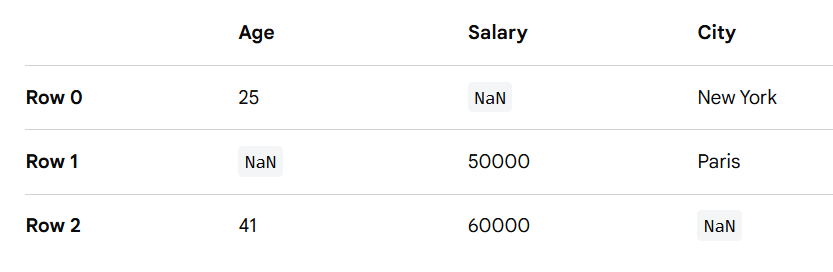

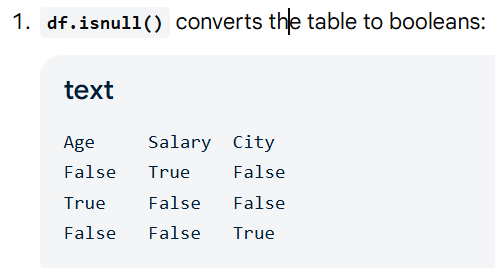

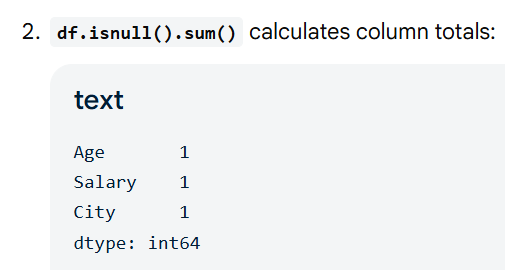

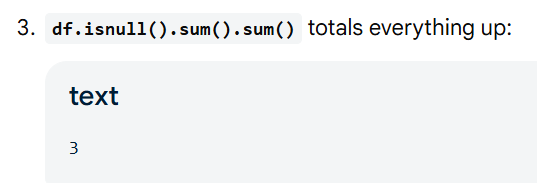

# Check duplicates:

In [5]:
print(df.duplicated().sum())

0


# Select the Variable

In [6]:
age = df["Age"]

# Mean

In [7]:
mean = age.mean()

print("Mean =", mean)

Mean = 36.923809523809524


# Median

In [8]:
median = age.median()

print("Median =", median)

Median = 36.0


# Mode

In [9]:
mode = age.mode()

print("Mode =", mode.tolist())

Mode = [35]


# Variance

In [10]:
variance = age.var()

print("Variance =", variance)

Variance = 83.45504878602227


In [11]:
population_variance = age.var(ddof=0)

print(population_variance)

83.39827664399097


# Standard Deviation

In [12]:
std = age.std()

print("Standard Deviation =", std)

Standard Deviation = 9.135373489136734


# Range

In [13]:
minimum = age.min()
maximum = age.max()

range_value = maximum - minimum

print("Minimum =", minimum)
print("Maximum =", maximum)
print("Range =", range_value)

# The employee ages range from 18 to 60 years, giving a total range of 42 years.

Minimum = 18
Maximum = 60
Range = 42


# Quartiles

In [14]:
Q1 = age.quantile(0.25)
Q2 = age.quantile(0.50)
Q3 = age.quantile(0.75)

print("Q1 =", Q1)
print("Q2 =", Q2)
print("Q3 =", Q3)

Q1 = 30.0
Q2 = 36.0
Q3 = 43.0


# IQR

In [15]:
IQR = Q3 - Q1

print("IQR =", IQR)

IQR = 13.0


# The dataset has an average employee age of approximately 37 years. The median is 36 and the mode is 35, indicating that the center of the age distribution is around the mid-30s. The standard deviation of 9.14 years indicates moderate variation, while the middle 50% of employees fall approximately between 30 and 43 years.

<!-- Raw Employee Dataset
        ↓
Understand Data
        ↓
Clean / Prepare Data
        ↓
Exploratory Data Analysis
        ↓
Univariate Analysis
        ↓
Bivariate Analysis
        ↓
Multivariate Analysis
        ↓
Visualization
        ↓
Find Patterns
        ↓
Obtain Insights -->

In [ ]:
Raw Employee Dataset
        ↓
Understand Data
        ↓
Clean / Prepare Data
        ↓
Exploratory Data Analysis
        ↓
Univariate Analysis
        ↓
Bivariate Analysis
        ↓
Multivariate Analysis
        ↓
Visualization
        ↓
Find Patterns
        ↓
Obtain Insights

# Univariate Analysis : Univariate = One variable, Let's analyze:Age

In [16]:
print(df["Age"].describe())

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64


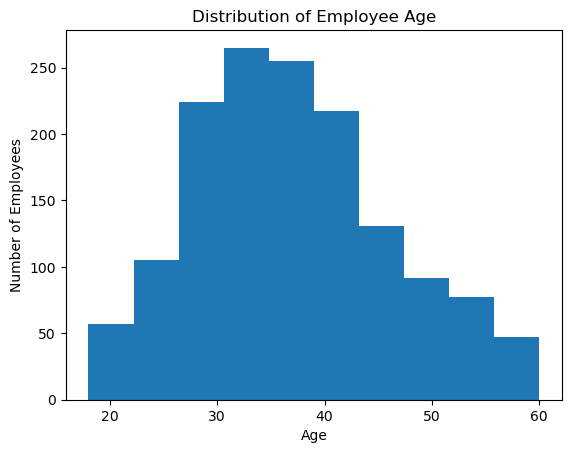

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10)

plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.title("Distribution of Employee Age")

plt.show()

# Bivariate Analysis : Bivariate = Two variables, Let's investigate: Age ↔ Monthly Income

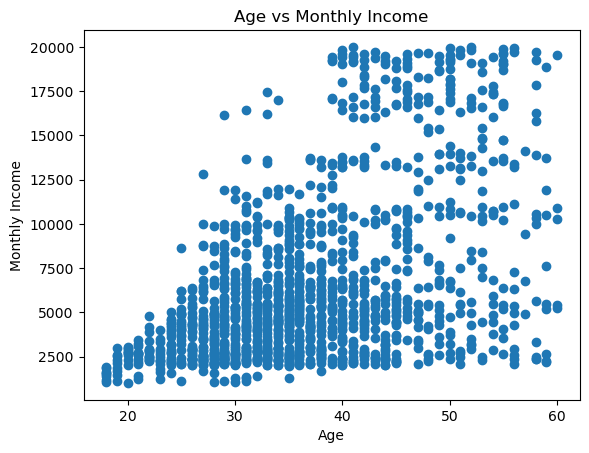

In [18]:
plt.scatter(df["Age"], df["MonthlyIncome"])

plt.xlabel("Age")
plt.ylabel("Monthly Income")
plt.title("Age vs Monthly Income")

plt.show()

In [19]:
correlation = df["Age"].corr(df["MonthlyIncome"])

print("Correlation =", correlation)

# Interpretation: There is a moderate positive relationship between age and monthly income in this dataset: as age tends to increase, monthly income also tends to increase.

Correlation = 0.49785456692658037


# Multivariate Analysis: Multivariate = Three or more variables: Age,Monthly Income,Years at Company,Total Working Years, Job Level

In [21]:
variables = ["Age","MonthlyIncome","YearsAtCompany","TotalWorkingYears"]

correlation_matrix = df[variables].corr()

print(correlation_matrix.round(2))

                    Age  MonthlyIncome  YearsAtCompany  TotalWorkingYears
Age                1.00           0.50            0.31               0.68
MonthlyIncome      0.50           1.00            0.51               0.77
YearsAtCompany     0.31           0.51            1.00               0.63
TotalWorkingYears  0.68           0.77            0.63               1.00


# Visualize the Multivariate Relationship

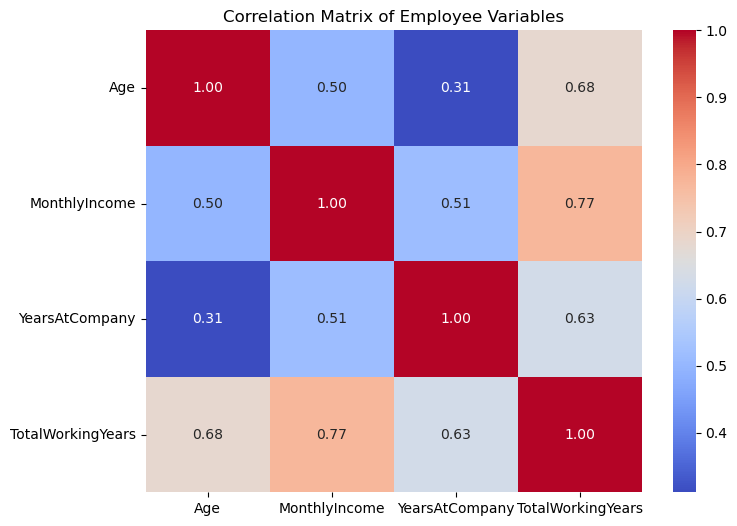

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Employee Variables")
plt.show()